In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('./data/titanic.csv')

In [ ]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
478,479,0,3,"Karlsson, Mr. Nils August",male,22.0,0,0,350060,7.5208,NaN,S
772,773,0,2,"Mack, Mrs. (Mary)",female,57.0,0,0,S.O./P.P. 3,10.5000,E77,S
642,643,0,3,"Skoog, Miss. Margit Elizabeth",female,2.0,3,2,347088,27.9000,NaN,S


In [ ]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


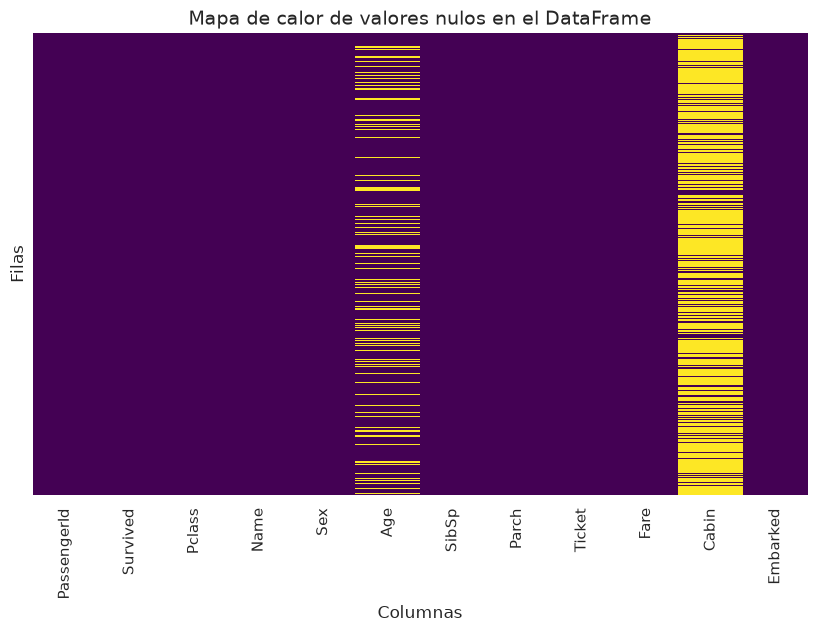

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Crear el mapa de calor con los valores nulos (True para nulos, False para no nulos)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# Añadir título y etiquetas
plt.title('Mapa de calor de valores nulos en el DataFrame', fontsize=14)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Filas', fontsize=12)

# Mostrar la gráfica
plt.show()

In [ ]:
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


In [ ]:
# Elimina la columna 'Cabin' solo si existe, evitando el KeyError
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

/tmp/ipykernel_27319/3177645766.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos.index, y=nulos.values, palette='viridis')


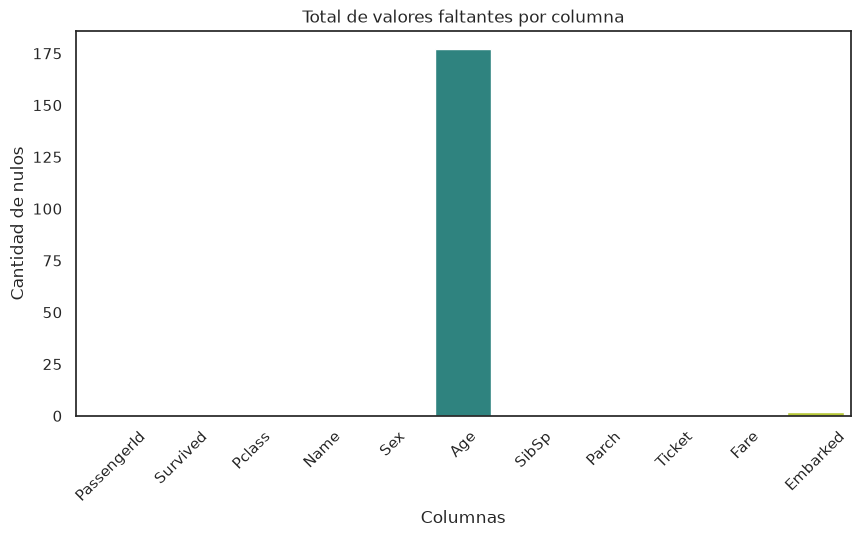

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular los valores nulos por columna
nulos = df.isnull().sum()

# Crear la gráfica de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=nulos.index, y=nulos.values, palette='viridis')
plt.title('Total de valores faltantes por columna')
plt.xlabel('Columnas')
plt.ylabel('Cantidad de nulos')
plt.xticks(rotation=45)
plt.show()# Elimina la columna 'Cabin' solo si existe, evitando el KeyError
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

In [ ]:
df.drop('Cabin', axis = 1, inplace = True)

KeyError: "['Cabin'] not found in axis"

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
round(df.isnull().sum().sort_values(ascending = False) / len(df) * 100, 2)

Age            19.87
Survived        0.00
PassengerId     0.00
Pclass          0.00
Name            0.00
Sex             0.00
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Embarked        0.00
dtype: float64

In [ ]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:

df.drop('Name', axis = 1, inplace = True)
df.drop('Ticket', axis = 1, inplace = True)
df.drop('PassengerId', axis = 1, inplace = True)

In [ ]:
print(f"Después de limpiar df: {df.shape[0]} filas y {df.shape[1]} columnas.")

Después de limpiar df: 891 filas y 8 columnas.


In [ ]:
df.to_csv('./data/titanic_clean.csv', index=False)